In [1]:
pip install tensorflow keras scikit-learn matplotlib seaborn pydot

In [2]:
# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pydot

# Evaluation Library
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

# Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

Step-by-step Process
--------------------

| Step |                 Process | Use                                  |
| ---- | ----------------------: | ------------------------------------ |
| 1    |      Load MNIST dataset | Load handwritten digit images        |
| 2    |   Split train/test data | Train and test separately            |
| 3    |        Visualize images | Understand dataset images            |
| 4    |             Check shape | Know image dimensions                |
| 5    |   Reshape `(28×28→784)` | Convert image into ANN input format  |
| 6    |        One-hot encoding | Convert labels into binary form      |
| 7    |       Create ANN layers | Build neural network                 |
| 8    |           Compile model | Define optimizer and loss function   |
| 9    |             Train model | Teach model patterns                 |
| 10   |                 Predict | Predict digits                       |
| 11   |              `argmax()` | Convert probabilities to final digit |
| 12   |        Confusion matrix | See correct/wrong predictions        |
| 13   |   Classification report | Get precision, recall, F1-score      |
| 14   |          Accuracy graph | Monitor learning                     |
| 15   |              Loss graph | Check overfitting                    |
| 16   | Single image prediction | Test individual images               |


In [3]:
(X_train_digit, y_train_digit), (X_test_digit, y_test_digit) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


| Variable      | Meaning         |
| ------------- | --------------- |
| X_train_digit | Training images |
| y_train_digit | Training labels |
| X_test_digit  | Testing images  |
| y_test_digit  | Testing labels  |

=============

Real-Life Example

Think like school learning:

| ANN Process     | Real-Life Meaning                    |
| --------------- | ------------------------------------ |
| Training Data   | Student studying old question papers |
| Training Labels | Correct answers                      |
| Testing Data    | New exam questions                   |
| Testing Labels  | Actual exam answers                  |



Visual Flow

MNIST Dataset
       ↓
mnist.load_data()
       ↓
--------------------------------
| Training Data   | Testing Data |
--------------------------------
| X_train_digit   | X_test_digit |
| y_train_digit   | y_test_digit |

In [4]:
X_train_digit

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [5]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [6]:
print(X_train_digit.shape)
print(y_train_digit.shape)

print(X_test_digit.shape)
print(y_test_digit.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


| Output  | Meaning          |
| ------- | ---------------- |
| 60000   | training images  |
| 10000   | testing images   |
| 28 × 28 | image pixel size |


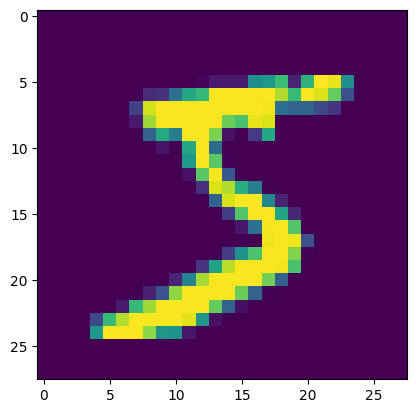

5


In [7]:
import matplotlib.pyplot as plt

plt.imshow(X_train_digit[0])
plt.show()

print(y_train_digit[0])

This shows:

first handwritten image
its correct digit label.

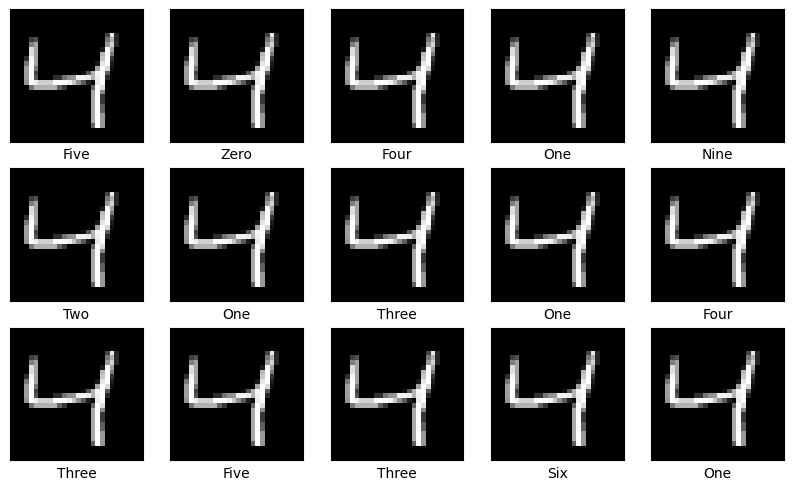

In [8]:
# Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four',
             'Five','Six','Seven','Eight','Nine']

# Visualizing the digits
plt.figure(figsize=(10,10))

for i in range(15):

    plt.subplot(5,5,i+1)

    plt.xticks([])
    plt.yticks([])

    plt.imshow(X_train_digit[2], cmap='gray')

    plt.xlabel(col_names[y_train_digit[i]])

plt.show()

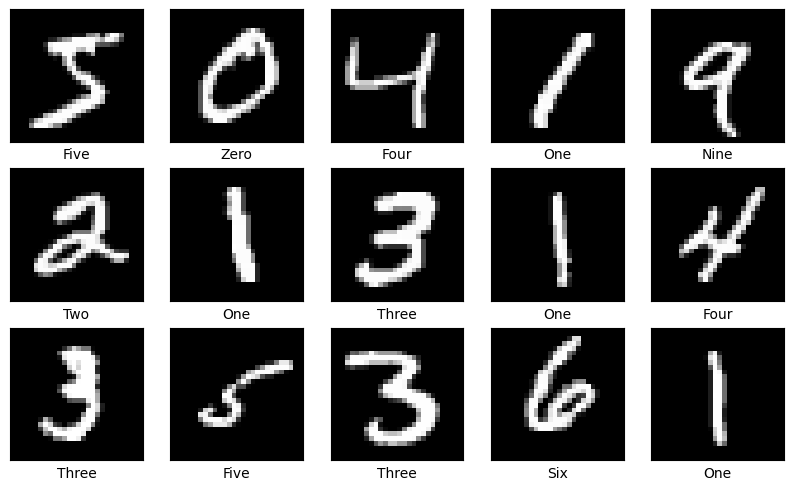

In [9]:
# Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four',
             'Five','Six','Seven','Eight','Nine']

# Visualizing the digits
plt.figure(figsize=(10,10))

for i in range(15):

    plt.subplot(5,5,i+1)

    plt.xticks([])
    plt.yticks([])

    plt.imshow(X_train_digit[i], cmap='gray')

    plt.xlabel(col_names[y_train_digit[i]])

plt.show()

In [10]:
X_train_digit[i]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1, 168,
        242,  28,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  10, 228,
        254, 100,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 190,
        254, 122,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  83,
        254, 162,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  29,
        254, 248,  25,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  29,
        255, 254, 103,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  29,
        254, 254, 109,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  29,
        254, 254, 109,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  29,
        254, 254, 109,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  29,
        255, 254, 109,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  29,
        254, 254, 109,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  29,
        254, 254,  63,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  29,
        254, 254,  28,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  29,
        254, 254,  28,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  29,
        254, 254,  35,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  29,
        254, 254, 109,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
        212, 254, 109,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        203, 254, 178,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        155, 254, 190,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

Step-by-step explanation
1. Create label names
col_names = ['Zero','One','Two','Three','Four',
             'Five','Six','Seven','Eight','Nine']

Stores digit names.

==========

| Index | Name |
| ----- | ---- |
| 0     | Zero |
| 1     | One  |
| 2     | Two  |

etc.
==========

2. Create figure size
plt.figure(figsize=(10,10))

Creates output image area.

Width = 10
Height = 10

============

3. Loop through images
for i in range(15):

Runs 15 times.

Values of i:

0,1,2,3....14

Shows first 15 digit images.

==========

4. Create subplot grid
plt.subplot(5,5,i+1)

Creates grid:

5 rows × 5 columns

i+1 means position number.

Example:

| i | Position |
| - | -------- |
| 0 | 1        |
| 1 | 2        |
| 2 | 3        |


===========

5. Remove x-axis numbers
plt.xticks([])

Removes x-axis markings.

==========

6. Remove y-axis numbers
plt.yticks([])

Removes y-axis markings.

==========

7. Display image
plt.imshow(X_train_digit[i], cmap='gray')

Shows handwritten digit image.

X_train_digit[i] → ith image
cmap='gray' → grayscale color

=========

8. Display label name
plt.xlabel(col_names[y_train_digit[i]])

Shows digit name below image.

Example:

Five
Two
Seven

=========

Explanation:

y_train_digit[i]

gives numeric label like:

5

Then:

col_names[5]

becomes:

Five

==========

9. Show all images
plt.show()

Displays final output.


In [11]:
y_train_digit[i]

np.uint8(1)

In [12]:
print(y_train_digit[0])

5


In [13]:
print(y_train_digit[1])

0


In [14]:
print(y_train_digit[2])

4


In [15]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

| Position | Digit |
| -------- | ----- |
| 0        | 5     |
| 1        | 0     |
| 2        | 4     |


Real-life example

Think about egg box:

Position 0 → Egg
Position 1 → Apple
Position 2 → Mango

If you ask:

give item at position 1

Answer:

Apple

Same concept.

==============================

Index      Image        Label
--------------------------------
0        handwritten 5    5
1        handwritten 0    0
2        handwritten 4    4
3        handwritten 1    1



In [16]:
print(X_train_digit.shape)
#print(y_train_digit.shape)

print(X_test_digit.shape)
#print(y_test_digit.shape)

(60000, 28, 28)
(10000, 28, 28)


In [17]:
print(X_train_digit.shape)
print(y_train_digit.shape)

print(X_test_digit.shape)
print(y_test_digit.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [18]:
X_train_digit = X_train_digit.reshape(60000, 784)
X_test_digit = X_test_digit.reshape(10000, 784)

3D convert into 2D

In [19]:
X_train_digit.shape


(60000, 784)

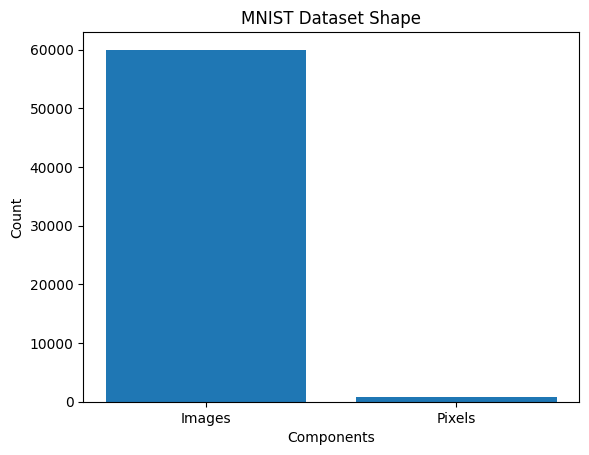

In [20]:
import matplotlib.pyplot as plt

# Data
dimensions = ['Images', 'Pixels']
values = [60000, 784]

# Graph
plt.bar(dimensions, values)

plt.title("MNIST Dataset Shape")
plt.xlabel("Components")
plt.ylabel("Count")

plt.show()

60000 images
784 pixels/features per image

In [21]:
print("Before Reshape : (60000, 28, 28)  -> 3D")
print("After Reshape  : (60000, 784)    -> 2D")

Before Reshape : (60000, 28, 28)  -> 3D
After Reshape  : (60000, 784)    -> 2D


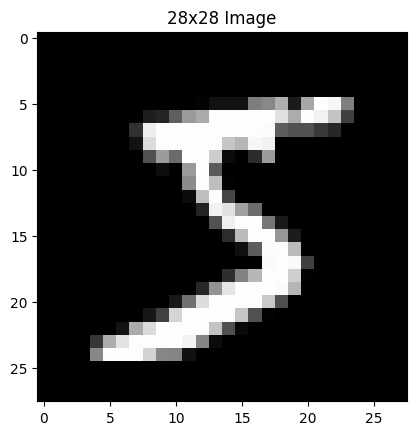

In [22]:
import matplotlib.pyplot as plt

# Original Image
plt.imshow(X_train_digit[0].reshape(28,28), cmap='gray')
plt.title("28x28 Image")
plt.show()

This shows:

original handwritten digit image
before flattening into 784 values.

In [23]:
X_train_digit

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [24]:
X_test_digit

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [25]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [26]:
y_test_digit

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [27]:
y_train_digit.shape

(60000,)

1D, tuple with one value (",")

In MNIST dataset:

Classes = categories/types of output

Here the categories are digits:

0 1 2 3 4 5 6 7 8 9

So total:

10 classes

==============

to_categorical(y_train_digit, num_classes=10)

means:

Convert labels into 10-class binary format

because there are 10 possible digits.

===============

Digit 3

Before encoding:

3

After encoding:

[0 0 0 1 0 0 0 0 0 0]

Position 3 becomes 1.

=============

ANN Output Layer

ANN final layer usually has:

10 neurons

Like:

0 1 2 3 4 5 6 7 8 9

Each neuron represents one class/digit.

========

Class = category/output type

encoding digit

In [28]:
y_train_digit = to_categorical(y_train_digit, num_classes=10)
y_test_digit = to_categorical(y_test_digit, num_classes=10)

In [29]:
y_train_digit[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [30]:
y_test_digit[1]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

One-Hot Encoding — Simple Explanation

One-hot encoding means:

Convert one number into binary category format
===========

Used in ANN classification problems.

Before One-Hot Encoding

Suppose labels are:

[5, 0, 2]

These are normal digit values.

======

Problem

ANN output layer has:

10 neurons

for digits:

0 1 2 3 4 5 6 7 8 9

=========

So ANN needs output like:

[0 0 0 0 0 1 0 0 0 0]

NOT just:

5
What One-Hot Encoding Does

It converts:

| Digit | One-Hot Encoded       |
| ----- | --------------------- |
| 0     | [1 0 0 0 0 0 0 0 0 0] |
| 1     | [0 1 0 0 0 0 0 0 0 0] |
| 2     | [0 0 1 0 0 0 0 0 0 0] |
| 5     | [0 0 0 0 0 1 0 0 0 0] |
| 9     | [0 0 0 0 0 0 0 0 0 1] |

============

In [31]:
# Creating base neural network
model = tf.keras.Sequential([

    # First Hidden Layer
    tf.keras.layers.Dense(256, activation='relu', input_shape=(784,)),

    # Dropout Layer (currently disabled)
    #tf.keras.layers.Dropout(0.3),

    # Batch Normalization Layer (currently disabled)
    #tf.keras.layers.BatchNormalization(),


    # Second Hidden Layer
    tf.keras.layers.Dense(64, activation='relu'),

    # Dropout Layer (currently disabled)
    #tf.keras.layers.Dropout(0.3),

    # Batch Normalization Layer (currently disabled)
    #tf.keras.layers.BatchNormalization(),


    # Third Hidden Layer
    tf.keras.layers.Dense(64, activation='relu'),

    # Batch Normalization Layer (currently disabled)
    #tf.keras.layers.BatchNormalization(),


    # Creating Output Layer
    tf.keras.layers.Dense(10, activation='sigmoid'),

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
# Creating base neural network
model = tf.keras.Sequential([

    # First Hidden Layer
    tf.keras.layers.Dense(256, activation='relu', input_shape=(784,)),

    # Second Hidden Layer
    tf.keras.layers.Dense(64, activation='relu'),

    # Third Hidden Layer
    tf.keras.layers.Dense(64, activation='relu'),

    # Creating Output Layer
    tf.keras.layers.Dense(10, activation='sigmoid'),

])

| Value | Fixed or Chosen?          |
| ----- | ------------------------- |
| 784   | Fixed from image size     |
| 10    | Fixed from output classes |
| 256   | Developer choice          |
| 64    | Developer choice          |


======

Input neurons  → depends on data
Output neurons → depends on classes
Hidden neurons → depends on experimentation

model = tf.keras.Sequential([
Meaning

Creating ANN model layer-by-layer in sequence.

Flow:

Input Layer
     ↓
Hidden Layers
     ↓
Output Layer

Sequential means:

layers arranged one after another.
# First Hidden Layer
Meaning

First learning layer of ANN.

This layer receives image pixel inputs.

===================

tf.keras.layers.Dense(256, activation='relu', input_shape=(784,)),
Meaning

Creating first hidden layer.

Break into parts
Dense
Dense

Means:

Fully connected layer

Every neuron connects to every neuron.

256
256

Means:

256 neurons.

These neurons learn patterns from image pixels.

========


activation='relu'

ReLU activation function:

f(x)=max(0,x)

Meaning:

Input	Output
-5	    0
 7     	7

Negative values become 0.

Positive values remain same.

================


input_shape=(784,)

Means:

784 input values

Why 784?

Because image size:

28×28=784

28×28 image converted into:

784 pixel values.
ANN Visual
784 Inputs
     ↓
256 Neurons

========


# Second Hidden Layer
Meaning

Second learning layer.

Learns deeper patterns from previous layer.

============

tf.keras.layers.Dense(64, activation='relu'),
Meaning

Creating:

64 neurons
using ReLU activation

This layer learns:

edges
curves
digit shapes
ANN Flow
256 Neurons
      ↓
64 Neurons

=======


# Third Hidden Layer
Meaning

Third learning layer.

Learns more advanced digit features.

tf.keras.layers.Dense(64, activation='relu'),
Meaning

Another:

64-neuron layer
ReLU activation

Improves feature learning.

ANN Flow
64 Neurons
     ↓
64 Neurons

========


# Creating Output Layer
Meaning

Final prediction layer.

This gives digit result.

tf.keras.layers.Dense(10, activation='sigmoid'),
Meaning

Creating:

10 output neurons
sigmoid activation
Why 10 neurons?

Digits are:

0 1 2 3 4 5 6 7 8 9

Total:

10 classes.

Each neuron predicts one digit.

==========


Sigmoid Activation

Sigmoid formula:

σ(x)=
1+e
−x
1
	​


Output range:

0 to 1

Used for probability prediction.

Example Output
[0.01, 0.02, 0.95, 0.03, ...]

Highest value = predicted digit.

Here:

digit 2 prediction highest.
])
Meaning

End of ANN model creation.

=========


Final ANN Architecture

784 Inputs
      ↓
256 Hidden Neurons
      ↓
64 Hidden Neurons
      ↓
64 Hidden Neurons
      ↓
10 Output Neurons

=========


Real-Life Analogy
----------------
Input Layer   → Eyes seeing image

Hidden Layers → Brain understanding
patterns

Output Layer  → Final digit answer

from tensorflow.keras.models import Sequential

=======

tf.keras.Sequential()
=========

Simple Analogy

Think:

TensorFlow = Big company
Keras = Tool inside company

So:

tf.keras

means:

Using Keras from TensorFlow
Why better?

tf.keras:

officially supported
more stable
compatible with latest TensorFlow
works properly in Colab/Jupyter

=========

Easy Memory Trick
tf = TensorFlow
keras = ANN building API

So:

tf.keras = ANN tools inside TensorFlow

=========


Layer names
Output shapes
Number of parameters

In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,218 (868.04 KB)

 Trainable params: 222,218 (868.04 KB)

 Non-trainable params: 0 (0.00 B)

Formula

For Dense layer:

#Parameters=(Input Neurons×Output Neurons)+Bias Neurons

1st Layer
Input = 784
Output neurons = 256

Calculation:

#(784x256)+256=200960


0r

# Parameter Formula
param_number = output_channel_number * (input_channel_number + 1)

Calculation:

256×(784+1)=200960

Result:

200,960 parameters

================



model.summary()

Result:

200,960

Exactly matches:

dense_4 → 200,960

Dense Layer — Very Simple

Dense = Everyone connected to everyone
------------------------------------

Dense

means:

Fully Connected Layer

=============

Simple Meaning

Every neuron connects to every neuron in next layer.
==============

Real-Life Example

Think classroom.

Input Layer Students
Student1
Student2
Student3

Hidden Layer Teachers
Teacher1
Teacher2
Teacher3

Dense means:

Every student talks to every teacher

All connections exist.

==============

ANN Example

Suppose:

784 input neurons

connected to:

256 hidden neurons

Dense layer creates:

All-to-all connections

Like:

Input1 → all 256 neurons
Input2 → all 256 neurons
Input3 → all 256 neurons

Visual Idea

Input Layer          Hidden Layer

        o  ─────────────►  o
        o  ─────────────►  o
        o  ─────────────►  o
        o  ─────────────►  o

Every node connected.
==================

In Your Code
tf.keras.layers.Dense(256)

Means:

Create dense layer with 256 neurons
Why called Dense?

Because connections are:

densely packed/full connections

No missing links.

===============


Real-Life Brain Analogy
-----------------------

Input neurons  → eyes seeing pixels
Dense layer    → brain processing everything together
=======================

Your Model

784 Inputs
     ↓ Dense
256 Neurons
     ↓ Dense
64 Neurons
     ↓ Dense
64 Neurons
     ↓ Dense
10 Outputs

=============




(None, 10)

means:

Output layer has 10 neurons

for digits:

0 to 9

#To see only output layer

In [34]:
print(model.layers[-1])

<Dense name=dense_7, built=True>


#To see number of neurons

In [35]:
print(model.layers[-1].units)

10


#To see activation function

In [36]:
print(model.layers[-1].activation)

<function sigmoid at 0x79fb23fac2c0>


model.layers[0] → First hidden layer
model.layers[1] → Second hidden layer
model.layers[2] → Third hidden layer
model.layers[3] → Output layer

In [37]:
model.layers[0]

<Dense name=dense_4, built=True>

In [38]:
model.layers[1]

<Dense name=dense_5, built=True>

In [39]:
model.layers[2]

<Dense name=dense_6, built=True>

In [40]:
model.layers[3]

<Dense name=dense_7, built=True>

In [41]:
#outer layer
model.layers[-1]

<Dense name=dense_7, built=True>

In [42]:
# Compiling the model
model.compile(
    loss='categorical_crossentropy',   # Loss Function
    optimizer='adam',                  # Optimizer
    metrics=['accuracy']               # Evaluation Metric
)

Full Flow
---------


Input Image
     ↓
Model Predicts
     ↓
Loss Function Checks Error
     ↓
Optimizer Corrects Weights
     ↓
Accuracy Displays Performance

============

Simple One-Line Meaning

| Command           | Meaning                    |
| ----------------- | -------------------------- |
| `model.compile()` | Prepare model for training |
| `loss`            | Calculate mistakes         |
| `optimizer`       | Improve model              |
| `metrics`         | Show performance           |

=====================================================

Line by Line Explanation

1)model.compile()

This command prepares the Neural Network for training.

Before training starts, TensorFlow needs to know:

How to calculate error
How to reduce error
What performance to display

Think of it like:

"Set the rules before starting the exam."

========



2) loss='categorical_crossentropy'

This tells the model:

"How much mistake did you make?"

This is called the Loss Function.

For digit classification (0–9):

Correct answer = one class
Output = probabilities

Example:

| Digit | Probability |
| ----- | ----------- |
| 0     | 0.01        |
| 1     | 0.02        |
| 2     | 0.90        |
| 3     | 0.03        |

Actual answer = 2

Model predicted 90% for digit 2 → small loss

If model predicts wrong number → high loss

Why categorical_crossentropy?

Used when:

Multiple classes exist
Output is one category among many

Example:

Digits 0–9
Cat/Dog/Bird
Apple/Mango/Banana

==========


3) optimizer='adam'

Optimizer improves the model.

Its job:

✅ Reduce errors
✅ Update weights
✅ Make predictions better

Adam uses:

Gradient Descent
Learning Rate
Momentum techniques

Think of Adam like:

"A smart teacher correcting mistakes after every test."

Real-time example

Suppose a student gets answers wrong.

Teacher says:

"You made mistake here."
"Study this topic more."

Same way:

Optimizer changes weights
Model slowly improves

======

4) metrics=['accuracy']

This tells TensorFlow:

"Show accuracy while training."

Accuracy means:

Accuracy=

(Correct Predictions/Total Predictions) x 100
	​

Example:

| Total Images | Correct Predictions |
| ------------ | ------------------- |
| 100          | 92                  |


Accuracy = 92%

============







In [43]:
#compiling the model

history = model.fit(
    X_train_digit,
    y_train_digit,
    batch_size=100,
    epochs=10,
    validation_data=(X_test_digit, y_test_digit)
)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6584 - loss: 1.2066 - val_accuracy: 0.7370 - val_loss: 0.3486
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7436 - loss: 0.2611 - val_accuracy: 0.7093 - val_loss: 0.2645
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7603 - loss: 0.1796 - val_accuracy: 0.7307 - val_loss: 0.2334
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7638 - loss: 0.1429 - val_accuracy: 0.7518 - val_loss: 0.1912
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7577 - loss: 0.1334 - val_accuracy: 0.7873 - val_loss: 0.1780
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7692 - loss: 0.1064 - val_accuracy: 0.7467 - val_loss: 0.1751
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7750 - loss: 0.1026 - val_accuracy: 0.8206 - val_loss: 0.1611
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7618 - loss: 0.0973 - val_accuracy:

Simple One-Line Meaning

| Code              | Meaning                    |
| ----------------- | -------------------------- |
| `model.fit()`     | Start training             |
| `X_train_digit`   | Training images            |
| `y_train_digit`   | Correct answers            |
| `batch_size=100`  | Train 100 samples together |
| `epochs=10`       | Repeat training 10 times   |
| `validation_data` | Test during training       |
| `history`         | Store training results     |


===========================

Full Training Process
---------------------

Input Images
      ↓
Forward Propagation
      ↓
Prediction
      ↓
Loss Calculation
      ↓
Optimizer Updates Weights
      ↓
Repeat for Every Batch
      ↓
Complete One Epoch
      ↓
Validation Testing

===========================

1️⃣ model.fit()

This command starts training the Neural Network.

Meaning:

"Train the model using given data."

Flow
Training Data
      ↓
Model Learns Patterns
      ↓
Weights Updated
      ↓
Accuracy Improves

=======================

2️⃣ X_train_digit

This is the input training data.

Contains:

Images of digits

Example:

Handwritten digit images (0–9)

X means:

Input features
Example
Image of digit 5
→ Given to Neural Network

=====================



3️⃣ y_train_digit

This is the correct output (labels).

Contains:

Actual answers

Example:

Image	Label

| Image       | Label |
| ----------- | ----- |
| Digit image | 5     |

=========================

y means:

Target output
4️⃣ batch_size=100

Means:

Train using 100 samples at one time.

Instead of training all images together:

Model splits data into small groups
Example

Suppose:

Total images = 60,000

Batch size = 100

Then:

Iterations per Epoch= 60000 / 1000 = 600

So:

600 batches processed in 1 epoch

======================

Real-time Example

Like:

Teacher checking 100 exam papers at once.
=====================

5️⃣ epochs=10

Means:

Entire dataset trained 10 times.

Example Flow
1 Epoch  → Full dataset trained once
2 Epochs → Full dataset trained twice
10 Epochs → Full dataset trained 10 times
Real-time Example

Like:

Revising same chapter 10 times before exam.

====================

6️⃣ validation_data=(X_test_digit, y_test_digit)

Used for:

Testing model performance during training.

After each epoch:

Model checks accuracy on test data

-------------------

Components

| Part           | Meaning             |
| -------------- | ------------------- |
| `X_test_digit` | Test input images   |
| `y_test_digit` | Correct test labels |


==================

Why Validation Needed?

To check:

Is model learning properly?
Is model overfitting?
Real-time Example

Like:

Mock test after studying.

=====================

7️⃣ history =

Stores training results.

Contains:

Accuracy
Loss
Validation accuracy
Validation loss
Example
history.history['accuracy']
history.history['loss']


Full Training Process
---------------------

Input Images
      ↓
Forward Propagation
      ↓
Prediction
      ↓
Loss Calculation
      ↓
Optimizer Updates Weights
      ↓
Repeat for Every Batch
      ↓
Complete One Epoch
      ↓
Validation Testing

=====================


To increase accuracy to 0.90 etc., we use

# Dropout Layer (currently disabled)
    tf.keras.layers.Dropout(0.3),

# Batch Normalization Layer (currently disabled)
    tf.keras.layers.BatchNormalization(),




In [44]:
# Creating base neural network
model = tf.keras.Sequential([

    # First Hidden Layer
    tf.keras.layers.Dense(256, activation='relu', input_shape=(784,)),

    # Dropout Layer (currently disabled)
    tf.keras.layers.Dropout(0.3),

    # Batch Normalization Layer (currently disabled)
    tf.keras.layers.BatchNormalization(),


    # Second Hidden Layer
    tf.keras.layers.Dense(64, activation='relu'),

    # Dropout Layer (currently disabled)
    #tf.keras.layers.Dropout(0.3),

    # Batch Normalization Layer (currently disabled)
    #tf.keras.layers.BatchNormalization(),


    # Third Hidden Layer
    tf.keras.layers.Dense(64, activation='relu'),

    # Batch Normalization Layer (currently disabled)
    #tf.keras.layers.BatchNormalization(),


    # Creating Output Layer
    tf.keras.layers.Dense(10, activation='sigmoid'),

])

In [45]:
# Again Compiling the model

model.compile(
    loss='categorical_crossentropy',   # Loss Function
    optimizer='adam',                  # Optimizer
    metrics=['accuracy']               # Evaluation Metric
)
history = model.fit(
    X_train_digit,
    y_train_digit,
    batch_size=100,
    epochs=10,
    validation_data=(X_test_digit, y_test_digit)
)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9074 - loss: 0.3073 - val_accuracy: 0.9618 - val_loss: 0.1201
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9564 - loss: 0.1406 - val_accuracy: 0.9719 - val_loss: 0.0949
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9649 - loss: 0.1131 - val_accuracy: 0.9720 - val_loss: 0.0935
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9695 - loss: 0.0960 - val_accuracy: 0.9757 - val_loss: 0.0902
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9722 - loss: 0.0873 - val_accuracy: 0.9774 - val_loss: 0.0833
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9750 - loss: 0.0775 - val_accuracy: 0.9789 - val_loss: 0.0720
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9774 - loss: 0.0696 - val_accuracy: 0.9809 - val_loss: 0.0745
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9786 - loss: 0.0659 - val_accuracy: 0

In [48]:
y_predict = model.predict(X_test_digit)
y_predict[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([5.7117228e-04, 2.4902159e-01, 2.2794545e-01, 6.2307161e-01,
       1.1079450e-03, 1.8778762e-02, 4.2418719e-06, 9.9999839e-01,
       8.2724374e-03, 5.6248790e-01], dtype=float32)

In [50]:
import numpy as np
# Convert 'predicted probabilities' into final digit labels
y_predicts = np.argmax(y_predict, axis=1)

In [51]:
print(y_predicts.dtype)

int64


In [52]:
y_predicts

array([7, 2, 1, ..., 4, 5, 6])

In [53]:
# Convert one-hot encoded 'actual' labels into normal digit labels
y_test_digit_eval = np.argmax(y_test_digit, axis=1)

In [54]:
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6])

In [55]:
# Predicting the Labels-DIGIT
y_predict = model.predict(X_test_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


| Code                | Meaning                        |
| ------------------- | ------------------------------ |
| `model.predict()`   | Predict outputs                |
| `X_test_digit`      | Test images                    |
| `y_predict`         | Predicted probabilities        |
| `np.argmax()`       | Find highest probability index |
| `axis=1`            | Row-wise checking              |
| `y_test_digit_eval` | Actual labels converted back   |


Test Image
     ↓
model.predict()
     ↓
Probability Output
     ↓
argmax()
     ↓
Final Digit Prediction

================

10,000 test images
       ↓
Split into small groups of 32
       ↓
313 prediction steps needed

=================


In [ ]:
import numpy as np
y_test_digit_eval = np.argmax(y_test_digit, axis=1)

Why axis=1?

Because:

Each row represents one image label

# axis=1 means:

Search across columns in each row.

Flow
One-Hot Encoded Labels
        ↓
np.argmax()
        ↓
Normal Digit Labels
        ↓
Easy Comparison with Predictions

Final Purpose

This code converts:

[0,0,0,0,0,1,0,0,0,0]

into:

5

so we can compare:

#Predicted Digit == Actual Digit

correctly.

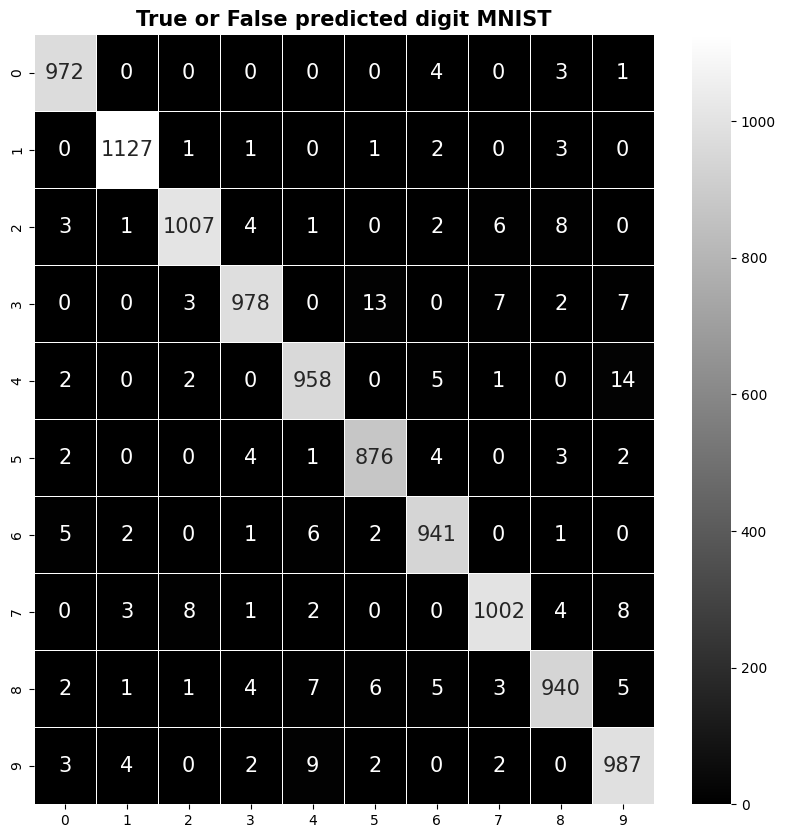

In [56]:
# Confusion matrix for Digit MNIST

con_mat = confusion_matrix(y_test_digit_eval, y_predicts)

plt.figure(figsize=(10,10))

sns.heatmap(
    con_mat,
    annot=True,
    annot_kws={'size':15},
    linewidths=0.5,
    fmt='d',
    cmap="gray"
)

plt.title(
    'True or False predicted digit MNIST',
    fontweight='bold',
    fontsize=15
)

plt.show()

This image is called a Confusion Matrix.

It shows:

#Which digits were predicted correctly
and
#Which digits were predicted wrongly.

Simple Rule
Rows → Actual Digits
Columns → Predicted Digits

=============



| Part            | Meaning             |
| --------------- | ------------------- |
| Rows            | Actual digits       |
| Columns         | Predicted digits    |
| Diagonal values | Correct predictions |
| Other values    | Wrong predictions   |
| White cells     | Large counts        |
| Black cells     | Small counts        |

=======================

Easy Understanding

Suppose we check this box:

| Row | Column | Meaning                 |
| --- | ------ | ----------------------- |
| 3   | 3      | Actual 3 predicted as 3 |




MNIST means:

#Modified National Institute of Standards and Technology

It is a very famous dataset used in Deep Learning and Machine Learning.

What is inside MNIST?

MNIST contains:

Handwritten digit images

Digits:

0
1
2
...
9
---------


Dataset Details

| Type            | Count  |
| --------------- | ------ |
| Training Images | 60,000 |
| Testing Images  | 10,000 |

=========

Each image size:

28 x 28

pixels.

==============

Why MNIST is Popular?

Used for:

Learning Neural Networks
Image Classification
Deep Learning beginners

Because:
✅ Small dataset
✅ Easy to understand
✅ Fast training

=========

Think of MNIST like:

School handwriting exam papers

Neural Network learns:

Which image is digit 0
Which image is digit 1
etc.

Then predicts new handwritten digits.

| Row | Column | Meaning                 |
| --- | ------ | ----------------------- |
| 3   | 3      | Actual 3 predicted as 3 |

======

Value:

982

Meaning:

982 images of digit 3 were predicted correctly ✅

=========

Main Important Part
Diagonal Values (White Boxes)

These are:

Correct predictions

Examples:

| Digit | Correct Predictions |
| ----- | ------------------- |
| 0     | 969                 |
| 1     | 1129                |
| 2     | 1016                |
| 3     | 982                 |


=============

Large diagonal numbers = Good model ✅

==========

Wrong Predictions

Non-diagonal values mean mistakes.

Example

Look at:

| Row | Column | Value |
| --- | ------ | ----- |
| 9   | 7      | 15    |

Meaning:

Actual digit = 9
Predicted digit = 7

15 times model got confused.

=====

Another Example

| Row | Column | Value |
| --- | ------ | ----- |
| 4   | 9      | 10    |


Meaning:

Actual digit = 4
Predicted digit = 9

10 wrong predictions

============







In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test_digit_eval, y_predicts))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.98      0.97      0.98      1010
           4       0.97      0.98      0.97       982
           5       0.97      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



For digit 1
------------
1    0.99    0.99    0.99    1135

Meaning:

#Out of 1135 images of digit 1, model predicted almost perfectly.

================

Similar for all digits (2–9)

Most values are 0.97–0.99

This means:

✅ Model recognizes almost every digit correctly
✅ Very few wrong predictions
✅ Balanced performance

==============

Bottom part:
-----------
#accuracy
----------

#accuracy      0.98    10000

Meaning:

Out of 10,000 test images

Correct predictions ≈ 9800
Wrong predictions ≈ 200

So:

Accuracy = 98%

========================

#Macro Average
-------------

macro avg   0.98   0.98   0.98

Meaning:

Take all digits 0-9 and give equal importance to every digit.

Simple example:

Digit 0 score = 98%
Digit 1 score = 99%
Digit 2 score = 98%
...

Average = 98%

====================

#Weighted Average
-----------------

weighted avg   0.98   0.98   0.98

Meaning:

Average considering the number of samples in each digit.

Example:

Digit 1 has 1135 images
Digit 5 has 892 images

Digit 1 affects the average more because it has more data.

============

#Conclusion:

Your ANN learned handwritten digits very well and predicts about 98 out of every 100 images correctly.

===========








In [58]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


print(history.history.keys()) is used to see what information was saved during model training.

==========
| Key            |                            Meaning |
| -------------- | ---------------------------------: |
| `loss`         |              Training error values |
| `accuracy`     |           Training accuracy values |
| `val_loss`     |    Validation/testing error values |
| `val_accuracy` | Validation/testing accuracy values |

=========




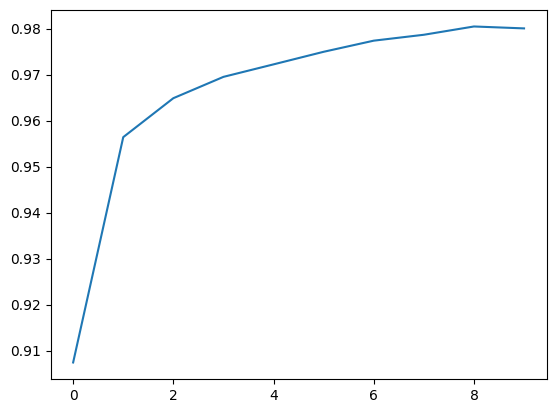

In [60]:
plt.plot(history.history['accuracy'])

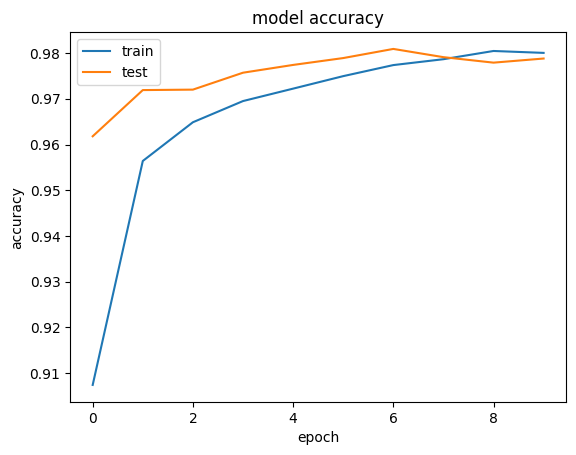

In [61]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

Legend means a label or key that explains symbols, colors, or lines.

In graphs:

plt.legend(['train','test'])

means:

#train → Blue line
#test  → Orange line

So the legend helps identify what each line represents.

Real-life examples:

 Map

#Red line → Highway
#Blue line → River

The small explanation box is called Legend

Graph

Blue line → Training accuracy
Orange line → Validation accuracy

The explanation box is called Legend

Simple definition:

#Legend = Description box that tells what each color, line, or symbol means.

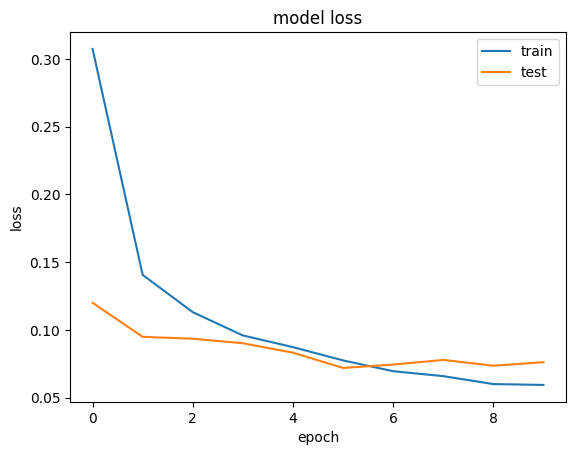

In [64]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

Simple meaning:

plt.plot(history.history['loss'])
→ plots training loss
plt.plot(history.history['val_loss'])
→ plots validation/testing loss
plt.title('model loss')
→ gives graph title "model loss"
plt.ylabel('loss')
→ Y-axis = loss values
plt.xlabel('epoch')
→ X-axis = epoch number
plt.legend(['train', 'test'], loc='best')
→ shows labels for the two lines and places them automatically in the best location
plt.show()
→ displays the graph

Simple interpretation of the graph:

# If loss decreases with epochs → model is learning correctly

#If training loss decreases but validation loss increases → possible overfitting

**Training and validation loss decrease steadily, showing the model is learning well.

**Both curves stay close together, indicating good performance with minimal overfitting.

================

Simple conclusion for your graph:

✅ Training loss is decreasing (0.31 → 0.06)
✅ Validation/Test loss is also decreasing (0.12 → ~0.07)
✅ Model is learning correctly
✅ Training and testing lines are very close
✅ No major overfitting

Small observation:

At around epoch 6–9, the validation loss slightly increases:

Train loss → 0.07 → 0.06 ↓
Test loss  → 0.07 → 0.08 ↑ (slightly)

This means the model may be starting to overfit a little, but it is very small and not serious

In [65]:
# tf.expand_dims(X_test_digit[0])

y_predict_single = model.predict(X_test_digit[[2]])
y_predicts_single = np.argmax(y_predict_single, axis=1) ## Here we get the index of maximum value in the encoded vector

y_test_digit_eval = np.argmax(y_test_digit, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


predict() → predicts image

argmax() → gets highest value index (actual digit)

argmax(y_test_digit) → converts
one-hot labels to normal digits

expand_dims() → adds extra dimension for model input

===========

Overall use of these commands in one line:

Select a test image

Predict the digit using the trained model

Convert prediction probabilities into the actual digit number

Convert one-hot encoded labels into normal labels

Compare actual digit vs predicted digit

================

Simple overall statement for notes:

"These commands are used to predict a single image from the test dataset and compare the model's predicted digit with the actual digit."

==============

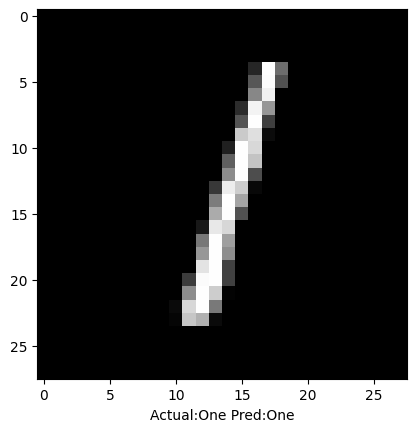

In [69]:
# Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four',
             'Five','Six','Seven','Eight','Nine']

# Visualizing the digit
# plt.figure(figsize=(10,10))
plt.imshow(X_test_digit[2].reshape(28,28), cmap='gray')

plt.xlabel(
    'Actual:{} Pred:{}'.format(
        col_names[np.argmax(y_test_digit[2])],
        col_names[y_predicts_single[0]]
    )
)

plt.show()

In [70]:
i = np.where(np.argmax(y_test_digit, axis=1)==3)[0][0]

This command automatically finds the first image index containing digit 3 from the test dataset.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


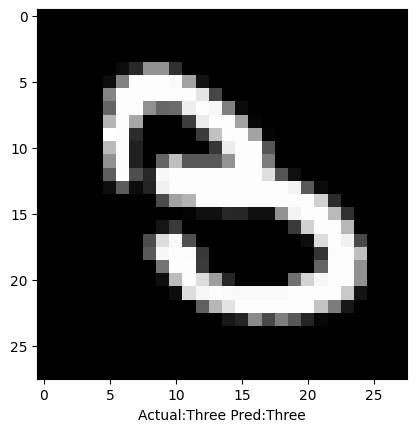

In [74]:
i = np.where(np.argmax(y_test_digit, axis=1)==3)[0][0]

y_predict_single = model.predict(X_test_digit[[i]])
y_predicts_single = np.argmax(y_predict_single, axis=1)

plt.imshow(X_test_digit[i].reshape(28,28), cmap='gray')

plt.xlabel(
    'Actual:{} Pred:{}'.format(
        col_names[np.argmax(y_test_digit[i])],
        col_names[y_predicts_single[0]]
    )
)

plt.show()

| Index | Actual Digit       |
| ----- | ------------------ |
| 0     | 7                  |
| 1     | 2                  |
| 2     | 1                  |
| 3     | 0                  |
| 4     | 4                  |
| 5     | 1                  |
| 6     | 4                  |
| 7     | 9                  |
| 8     | 5 ← selected image |


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


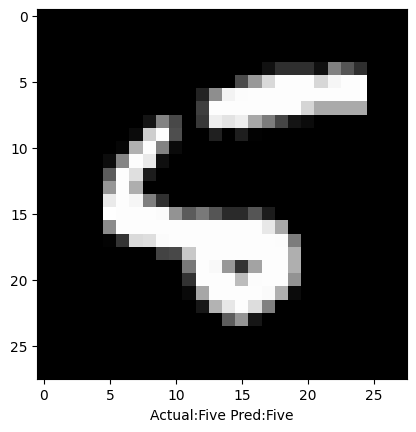

In [75]:
i = np.where(np.argmax(y_test_digit, axis=1)==5)[0][0]

y_predict_single = model.predict(X_test_digit[[i]])
y_predicts_single = np.argmax(y_predict_single, axis=1)

plt.imshow(X_test_digit[i].reshape(28,28), cmap='gray')

plt.xlabel(
    'Actual:{} Pred:{}'.format(
        col_names[np.argmax(y_test_digit[i])],
        col_names[y_predicts_single[0]]
    )
)

plt.show()